In [272]:
from spin_lattices import KagomeLattice, SpinLattice, SquareLattice, TriangleLattice
from heisenberg_hamiltonians import HeisenbergJ1J2, SpinSystem
from pathlib import Path
import torch
from tqdm.auto import tqdm
from torch.optim import Adam
import numpy as np
import numpy.typing as npt
from utils import make_unpacked_configurations
from torch.utils.tensorboard import SummaryWriter
from datetime import datetime
import torch
import torch.nn as nn
import torch.nn.functional as F

import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.optim as optim

import matplotlib.pyplot as plt

from sympy.combinatorics import Permutation
from sympy.combinatorics.perm_groups import PermutationGroup

from collections.abc import Iterable
import itertools


In [279]:
def vis_permutation(lat: SpinLattice, permutation: list[int]):
    lat.plot()
    for _, row in lat.sites_df.iterrows():
        plt.text(row['emb_x'] + 0.2, row['emb_y'] + 0.2, "(" + str(permutation[row['num']]) + ")")

def train_test_split(X: torch.Tensor, Y: torch.Tensor, train_ratio=0.8):
    N = len(Y)
    train_size = int(N * train_ratio)
    idxs = np.arange(N)
    np.random.shuffle(idxs)
    train_idxs = idxs[:train_size]
    test_idxs = idxs[train_size:]
    return X[train_idxs], Y[train_idxs], X[test_idxs], Y[test_idxs]

In [132]:
state = make_unpacked_configurations(np.random.choice(system.basis.states), number_spins=system.number_spins)

<AxesSubplot: xlabel='emb_x', ylabel='emb_y'>

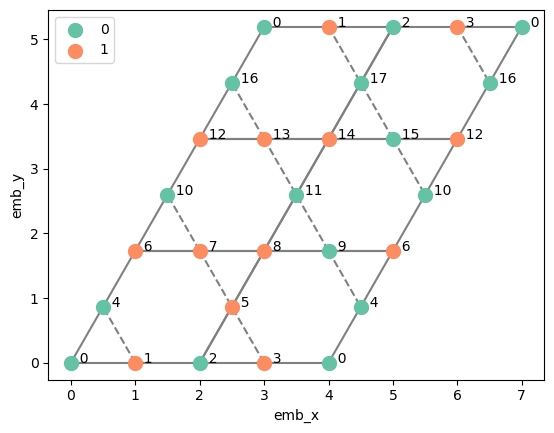

In [133]:
lattice.plot(spins=state)

In [134]:
def inv_perm(perm: list[int]) -> list[int]:
    return (~Permutation(perm)).array_form

<AxesSubplot: xlabel='emb_x', ylabel='emb_y'>

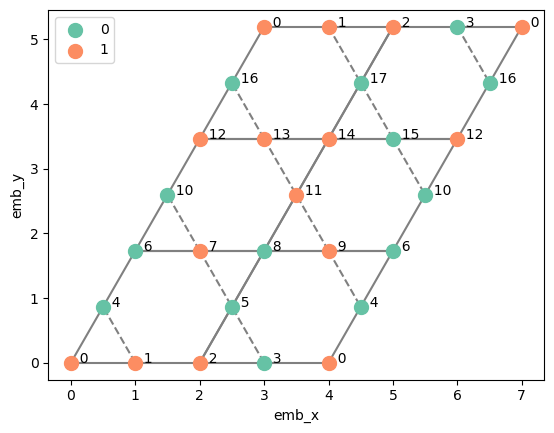

In [135]:
lattice.plot(spins=state[inv_perm(lattice.get_translation("y"))])

In [136]:
def one(iterable: Iterable):
    it = iter(iterable)
    x = next(it)
    try:
        next(it)
    except StopIteration:
        return x
    raise ValueError("More than one element in iterable")

In [206]:
def self_action(g: Permutation, group_elements: list[Permutation]) -> Permutation:
    # permutation acts from the right, so it's h * g instead of g * h
    return Permutation([group_elements.index(h * g) for h in group_elements])

In [139]:
group_elements[0].array_form

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]

In [214]:
class GConvGrid(nn.Module):
    def __init__(
        self,
        group_elements: list[Permutation],
        filter_idxs: list[int] | torch.Tensor,
        out_channels: int,
    ):
        super().__init__()
        self.filter_size = len(filter_idxs)
        self.out_channels = out_channels
        self.filter_idxs = filter_idxs
        self.group_elements = group_elements
        self.inv_group_elements_tensor = torch.tensor(
            [(~g).array_form for g in self.group_elements], dtype=torch.long
        )
        self.number_spins = self.inv_group_elements_tensor.size()[1]
        self.filter = nn.Parameter(torch.empty(out_channels, self.filter_size))
        torch.nn.init.xavier_uniform_(self.filter)
        self.filter.requires_grad = True

    def _forward_reference(self, batch: torch.Tensor):
        output = torch.zeros((batch.size()[0], self.out_channels, len(self.group_elements)))
        filter_extended = torch.zeros((self.out_channels, self.number_spins))
        filter_extended[:, self.filter_idxs] = self.filter

        for i, g in enumerate(self.group_elements):
            permuted_filter = filter_extended[:, (~g).array_form]
            output[:, :, i] = torch.einsum("bn,an->ba", batch, permuted_filter)
        return output

    def forward(self, batch: torch.Tensor):
        filter_extended = torch.zeros((self.out_channels, self.number_spins))

        
        filter_extended[:, self.filter_idxs] = self.filter

        permuted_filters = filter_extended[:, self.inv_group_elements_tensor.view(-1)].view(
            self.out_channels, len(self.group_elements), self.number_spins
        )

        output = torch.einsum("bs,ogs->bog", batch, permuted_filters)
        return output

<AxesSubplot: xlabel='emb_x', ylabel='emb_y'>

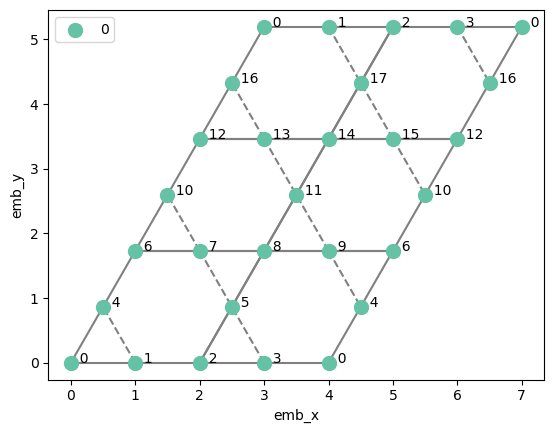

In [215]:
lattice.plot()

In [216]:
X = torch.tensor(
    make_unpacked_configurations(
        system.basis.states[:10], number_spins=system.number_spins
    ).astype(np.float32),
)

# filter_idxs = [
#     group_elements.index(tx**a * ty**b * sym**c)
#     for a, b, c in itertools.product(range(2), range(2), range(2))
# ]
filter_idxs = torch.arange(12)

layer = GConvGrid(
    group_elements=group_elements,
    filter_idxs=filter_idxs,
    out_channels=3,
)
layer(X)
assert torch.allclose(layer(X), layer._forward_reference(X), atol=1e-7)

In [217]:
class GConvG(nn.Module):
    def __init__(
        self,
        group_elements: list[Permutation],
        filter_idxs: list[int] | torch.Tensor,
        in_channels: int,
        out_channels: int,
    ):
        super().__init__()
        self.filter_size = len(filter_idxs)
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.filter_idxs = filter_idxs
        self.group_elements = group_elements
        self.inv_group_elements_tensor = torch.tensor(
            [(~self_action(g, group_elements)).array_form for g in self.group_elements], dtype=torch.long
        )
        self.filter = nn.Parameter(torch.empty(out_channels, in_channels, self.filter_size))
        torch.nn.init.xavier_uniform_(self.filter)
        self.filter.requires_grad = True

    def _forward_reference(self, batch: torch.Tensor):
        output = torch.zeros((batch.size()[0], self.out_channels, len(self.group_elements)))
        filter_extended = torch.zeros(
            (self.out_channels, self.in_channels, len(self.group_elements))
        )
        filter_extended[:, :, self.filter_idxs] = self.filter

        for action_index, action in enumerate(self.group_elements):
            permuted_filter = filter_extended[:, :, self_action(~action, self.group_elements).array_form]
            output[:, :, action_index] = torch.einsum("big,oig->bo", batch, permuted_filter)
            # b: batch, i: in_channels, g: group_elements, o: out_channels

        return output

    def forward(self, batch: torch.Tensor):
        output = torch.zeros((batch.size()[0], self.out_channels, len(self.group_elements)))
        filter_extended = torch.zeros(
            (self.out_channels, self.in_channels, len(self.group_elements))
        )
        filter_extended[:, :, self.filter_idxs] = self.filter

        permuted_filters = filter_extended[:, :, self.inv_group_elements_tensor.view(-1)].view(
            self.out_channels,
            self.in_channels,
            len(self.group_elements),
            len(self.group_elements),
        )

        return torch.einsum("big,oiag->boa", batch, permuted_filters)
        # b: batch, i: input channels, g: group element (as domain coordinate)
        # o: output channel, a: group element (as action)

In [218]:
lattice = KagomeLattice(2, 3, enumerate_along="x")
system = HeisenbergJ1J2(
    lattice=lattice,
    J2=0.8,
    use_symmetries=True,
    spin_inversion=1,
    ground_state_cache_dir=Path("groundstates"),
    skip_symmetries_whitelist=True,
)
system.get_eigenstates(1)

2023-06-26 16:34:57.489 | WARNING  | heisenberg_hamiltonians:__init__:414 - Symmetries are not tested with KagomeLattice2x3-enumerate-along-x, and can produce incorrect results. Using them anyway due to skip_symmetries_whitelist=True.
2023-06-26 16:34:57.490 | DEBUG    | heisenberg_hamiltonians:__init__:446 - number_spins=18
2023-06-26 16:34:57.495 | DEBUG    | heisenberg_hamiltonians:__init__:456 - Symmetry group contains 12 elements
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
2023-06-26 16:34:57.532 | DEBUG    | heisenberg_hamiltonians:__init__:465 - Hilbert space dimension is 2102
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
2023-06-26 16:34:57.549 | DEBUG    | heisenberg_hamiltonians:_find_cached_eigenstate:60 - Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x3-enumerate-along-x-1.0-0.8-True-1-1.pickle
2023-06-26 16:34:57.551 | DEBUG    | heisenberg_hamiltonians:get_eigenstates:107 - Ground state energ

(array([-29.49637433]),
 array([[ 2.45861402e-05],
        [ 4.60301334e-05],
        [-5.98187546e-05],
        ...,
        [ 3.85816233e-03],
        [-1.34561320e-02],
        [ 4.54259634e-02]]))

In [234]:
group_elements = [Permutation(g) for g in sorted(lattice.get_automorphisms())]
tx = Permutation(lattice.get_translation("x"))
ty = Permutation(lattice.get_translation("y"))
sym = one(
    g
    for g in group_elements
    if g.apply(0) == 0 and any(g.apply(x) != x for x in range(lattice.number_spins))
)
filter_idxs_2 = [
    group_elements.index(tx**a * ty**b * sym**c)
    for a, b, c in itertools.product(range(2), range(2), range(2))
]

In [235]:
X = torch.tensor(
    make_unpacked_configurations(
        system.basis.states[:10], number_spins=system.number_spins
    ).astype(np.float32),
)

In [233]:
layer1 = GConvGrid(group_elements=group_elements, filter_idxs=torch.arange(12), out_channels=3)
layer2 = GConvG(
    group_elements=group_elements, filter_idxs=filter_idxs_2, in_channels=3, out_channels=5
)

# assert equivariance
X = torch.tensor(
    make_unpacked_configurations(system.basis.states, number_spins=system.number_spins).astype(
        np.float32
    ),
)


def net(X):
    return layer2(layer1(X))


def net_reference(X):
    return layer2._forward_reference(layer1(X))


assert net(X).shape == (len(system.basis.states), 5, len(group_elements))
assert torch.allclose(net(X), net_reference(X), atol=1e-6)
for action in group_elements:
    assert torch.allclose(
        torch.relu(net(X[:, (~action).array_form])),
        torch.relu(net(X)[:, :, self_action(~action, group_elements).array_form]),
        atol=1e-6,
    )

In [222]:
def find_fundamental_domain(group_elements: list[Permutation]):
    site = 0
    remaining_sites = set(group_elements[0].array_form)
    fundamental_domain = [site]
    while True:
        remaining_sites -= set(g.apply(site) for g in group_elements)
        if not remaining_sites:
            break
        site = remaining_sites.pop()
        fundamental_domain.append(site)
        
    return fundamental_domain

In [223]:
find_fundamental_domain(
    [Permutation(g) for g in KagomeLattice(2, 3).get_automorphisms()]
)

[0, 1, 3]

<AxesSubplot: xlabel='emb_x', ylabel='emb_y'>

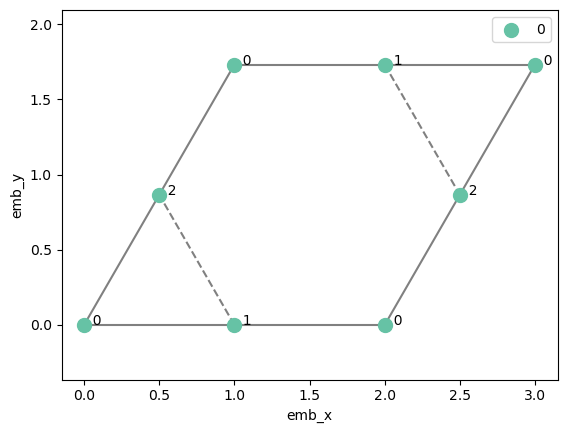

In [224]:
KagomeLattice(1, 1).plot()

In [251]:
class TxTySymKagomeConvNet2(nn.Module):
    def __init__(
        self,
        lattice: SpinLattice,
        filter_width=2,
        filter_height=2,
        use_sym=True,
        channels1=32,
        channels2=64,
    ):
        super().__init__()
        all_group_elements = [Permutation(g) for g in sorted(lattice.get_automorphisms())]
        tx = Permutation(lattice.get_translation("x"))
        ty = Permutation(lattice.get_translation("y"))
        sym = one(
            g
            for g in all_group_elements
            if g.apply(0) == 0 and any(g.apply(x) != x for x in range(lattice.number_spins))
        )
        fundamental_domain = find_fundamental_domain(all_group_elements)
        filter_idxs_1 = [
            int((tx**a * ty**b).apply(site))
            for site in fundamental_domain
            for a in range(filter_width)
            for b in range(filter_height)
        ]

        # It is possible that we are interested only in translation symmetry
        # in this case, we can set use_sym=False
        # then group_elements will be smaller than all_group_elements

        group_elements = [
            tx**a * ty**b * sym**c
            for a, b, c in itertools.product(
                range(lattice.width), range(lattice.height), range(use_sym + 1)
            )
        ]

        self.group_elements = group_elements

        self.layer1 = GConvGrid(
            group_elements=group_elements, filter_idxs=filter_idxs_1, out_channels=channels1
        )

        filter_idxs_2 = [
            group_elements.index(tx**a * ty**b * sym**c)
            for a, b, c in itertools.product(
                range(filter_width), range(filter_height), range(use_sym + 1)
            )
        ]

        self.layer2 = GConvG(
            group_elements=group_elements,
            filter_idxs=filter_idxs_2,
            in_channels=channels1,
            out_channels=channels2,
        )

        self.fc = nn.Linear(channels2, 1)

    def forward(self, x):
        x = self.layer1(x)
        x = torch.relu(x)
        x = self.layer2(x)
        x = torch.relu(x)
        x = x.mean(dim=2)
        x = self.fc(x)
        return x

In [252]:
def get_X_Y(system: SpinSystem, sample=None, target="amplitude"):
    ground_state_df = system.get_df_ground_state()
    if sample:
        ground_state_df = ground_state_df.sample(sample)
    Y = torch.Tensor(
        np.log(np.real_if_close(ground_state_df[target].to_numpy()).astype(np.float32))
    )
    X = torch.Tensor(
        make_unpacked_configurations(
            ground_state_df.index.to_numpy(), number_spins=system.number_spins
        ).astype(np.float32)
    )
    return X, Y


def overlap(x, y):
    return torch.sum(x * y) / torch.sqrt(torch.sum(x**2) * torch.sum(y**2))

In [258]:
# Test invariance

X, Y = get_X_Y(system)
for use_sym in [True, False]:
    model = TxTySymKagomeConvNet2(lattice=lattice, use_sym=use_sym)
    for g in model.group_elements:
        assert torch.allclose(
            model(X[:, g.array_form]), model(X[:]), atol=1e-6
        )

In [280]:
J2 = 0.8
lattice = KagomeLattice(2, 3, enumerate_along="x")
system = HeisenbergJ1J2(
    lattice=lattice,
    J2=J2,
    use_symmetries=True,
    spin_inversion=1,
    ground_state_cache_dir=Path("groundstates"),
    skip_symmetries_whitelist=True,
)
system.get_eigenstates(1)

lattice_target = KagomeLattice(2, 5, enumerate_along="x")
system_target = HeisenbergJ1J2(
    lattice=lattice_target,
    J2=J2,
    use_symmetries=True,
    spin_inversion=1,
    ground_state_cache_dir=Path("groundstates"),
    skip_symmetries_whitelist=True,
)
system_target.get_eigenstates(1)

2023-06-26 18:07:35.964 | WARNING  | heisenberg_hamiltonians:__init__:414 - Symmetries are not tested with KagomeLattice2x3-enumerate-along-x, and can produce incorrect results. Using them anyway due to skip_symmetries_whitelist=True.
2023-06-26 18:07:35.965 | DEBUG    | heisenberg_hamiltonians:__init__:446 - number_spins=18
2023-06-26 18:07:35.970 | DEBUG    | heisenberg_hamiltonians:__init__:456 - Symmetry group contains 12 elements


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
2023-06-26 18:07:36.007 | DEBUG    | heisenberg_hamiltonians:__init__:465 - Hilbert space dimension is 2102
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
2023-06-26 18:07:36.027 | DEBUG    | heisenberg_hamiltonians:_find_cached_eigenstate:60 - Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x3-enumerate-along-x-1.0-0.8-True-1-1.pickle
2023-06-26 18:07:36.029 | DEBUG    | heisenberg_hamiltonians:get_eigenstates:107 - Ground state energy is -29.4963743253
2023-06-26 18:07:36.070 | WARNING  | heisenberg_hamiltonians:__init__:414 - Symmetries are not tested with KagomeLattice2x5-enumerate-along-x, and can produce incorrect results. Using them anyway due to skip_symmetries_whitelist=True.
2023-06-26 18:07:36.071 | DEBUG    | heisenberg_hamiltonians:__init__:446 - number_spins=30
2023-06-26 18:07:36.077 | DEBUG    | heisenberg_hamiltonians:__init__:456 - Symmetry group c

(array([-50.04924351]),
 array([[ 4.01688396e-14],
        [ 3.08233662e-14],
        [-2.32074986e-13],
        ...,
        [ 3.06795594e-03],
        [-2.82381650e-03],
        [ 1.96499656e-04]]))

In [284]:
X, Y, X_test, Y_test = train_test_split(*get_X_Y(system, sample=20000), train_ratio=0.8)
X_target, Y_target = get_X_Y(system_target, sample=10000)


In [292]:
from torch.utils.tensorboard import SummaryWriter

# Initialize the model
channels1 = 16 * 8 * 4
channels2 = 32 * 8 * 4
use_sym = True
lr = 1e-4

model = TxTySymKagomeConvNet2(
    lattice=lattice, use_sym=use_sym, channels1=channels1, channels2=channels2
)
model_target = TxTySymKagomeConvNet2(
    lattice=lattice_target, use_sym=use_sym, channels1=channels1, channels2=channels2
)

# Check if a GPU is available and if not, use a CPU
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Move the model to the device (GPU or CPU)
model.to(device)

# Create a TensorDataset from your inputs X and Y
dataset = TensorDataset(X, Y)

# Create a DataLoader for your dataset with a batch size of 32 and shuffling
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

# Define a loss function - Mean Squared Error (MSE) for regression
criterion = torch.nn.MSELoss()

# Define an optimizer - Adam
optimizer = optim.Adam(model.parameters(), lr=lr)  # Learning rate

# Number of epochs (iterations over the entire dataset)
epochs = 500

# Create a SummaryWriter instance for TensorBoard
writer = SummaryWriter(
        log_dir=(
            f"experiments/2022_06_26/{datetime.now().strftime('%H_%M_%S')}"
            f"_{channels1=}_{channels2=}_{use_sym=}_{lr=}"
        )
    )
for epoch in range(epochs):
    running_loss = 0.0
    for action_index, data in enumerate(dataloader, 0):
        # Get the inputs and move them to the specified device
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(inputs)

        # Compute loss
        loss = criterion(outputs, labels.view(-1, 1))  # Reshape labels to match output shape

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

        # Collect loss
        running_loss += loss.item()

    # Add average loss per epoch to TensorBoard
    writer.add_scalar('Training Loss', running_loss / len(dataloader), epoch)
    
    # Calculate overlaps and add them to TensorBoard
    overlap_train = overlap(torch.exp(model(X).view(-1)), torch.exp(Y))
    overlap_test = overlap(torch.exp(model(X_test).view(-1)), torch.exp(Y_test))
    model_target.load_state_dict(model.state_dict())
    overlap_target = overlap(torch.exp(model_target(X_target).view(-1)), torch.exp(Y_target))
    
    writer.add_scalar('Overlap Train', overlap_train, epoch)
    writer.add_scalar('Overlap Test', overlap_test, epoch)
    writer.add_scalar('Overlap Target', overlap_target, epoch)

writer.close()
print("Finished Training")


NameError: name 'model_target' is not defined